In [1]:
from pathlib import Path
from readers import RawImage, RawSpecim
import matplotlib.pyplot as plt
import numpy as np
import math
from tqdm import tqdm
from scipy.interpolate import interp1d
import seaborn as sns
from pathlib import Path
import cv2
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import spectral.io.envi as envi

sns.set_theme('notebook')


In [2]:
base_path = Path("./data/flashlight")

In [3]:
def load_and_decode(phone_noflash_path, phone_flash_path, specim_dir):
    p_noflash = Path(phone_noflash_path)
    p_flash = Path(phone_flash_path)
    p_specim = Path(specim_dir)

    raw_noflash = RawImage.from_file(p_noflash)
    img_noflash_norm = raw_noflash.get_exposure_normalized_img(exposure=True, iso=True)

    raw_flash = RawImage.from_file(p_flash)
    img_flash_norm = raw_flash.get_exposure_normalized_img(exposure=True, iso=True)

    raw_specim = RawSpecim.from_directory(p_specim)
    img_specim_norm = raw_specim.get_exposure_normalized_img()

    scene_data = {
        "noflash": img_noflash_norm,
        "flash": img_flash_norm,
        "specim": img_specim_norm,
        "wavelengths": raw_specim.wavelengths
    }

    return scene_data

In [4]:
def interpolate_specim(specim_obj, start_wl=400, end_wl=700, num_bands=31):
    """
    Интерполирует в заданный диапазон
    """
    target_wavelengths = np.linspace(start_wl, end_wl, num_bands)

    interpolator = interp1d(
        specim_obj.wavelengths,
        specim_obj._img_int,
        axis=-1,
        kind='linear',
        bounds_error=False,
        fill_value='extrapolate'
    )

    resampled_cube = interpolator(target_wavelengths)

    resampled_cube = np.clip(resampled_cube, 0, None)

    return resampled_cube, target_wavelengths

def interpolate_cube_to_31(cube_raw, specim_wls):
    target_wls = np.linspace(400, 700, 31)

    H, W, C = cube_raw.shape
    flat_cube = cube_raw.reshape(-1, C)

    interp_func = interp1d(specim_wls, flat_cube, axis=1, kind='linear', fill_value="extrapolate")
    flat_cube_31 = interp_func(target_wls)

    cube_31 = flat_cube_31.reshape(H, W, len(target_wls))

    return cube_31, target_wls

def get_approx_rgb(cube, wavelengths):
    """
    Собирает false RGB изображение (просто выбираем похожие длины волн)
    """
    r_idx = np.argmin(np.abs(wavelengths - 650.0))
    g_idx = np.argmin(np.abs(wavelengths - 550.0))
    b_idx = np.argmin(np.abs(wavelengths - 450.0))

    rgb_img = cube[:, :, [r_idx, g_idx, b_idx]].astype(np.float32)

    for i in range(3):
        ch = rgb_img[:, :, i]
        p_low, p_high = np.percentile(ch, 1), np.percentile(ch, 99)
        ch = np.clip((ch - p_low) / (p_high - p_low + 1e-6), 0, 1)
        rgb_img[:, :, i] = ch

    return rgb_img

def visualize_all_specim_cubes(base_dir="."):
    """
    Находит все папки Specim, обрабатывает и выводит сеткой.
    """
    base_path = Path(base_dir)

    specim_dirs = sorted([d for d in base_path.iterdir() if d.is_dir() and d.name.startswith("08")])

    cols = 3
    rows = math.ceil(len(specim_dirs) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten()

    print(f"Найдено {len(specim_dirs)} Specim")

    for i, specim_dir in enumerate(specim_dirs):
        raw_specim = RawSpecim.from_directory(specim_dir)

        cube_31, wls_31 = interpolate_specim(raw_specim)

        approx_rgb = get_approx_rgb(cube_31, wls_31)

        axes[i].imshow(approx_rgb)
        axes[i].set_title(f"Сцена: {specim_dir.name}\nРазмер: {cube_31.shape}")


        axes[i].axis('off')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

In [5]:
def load_reflectance_from_results(directory_path):
    """
    Загружает Reflectance из папки results.
    """
    dir_path = Path(directory_path)
    scene_name = dir_path.name

    hdr_path = dir_path / "results" / f"REFLECTANCE_{scene_name}.hdr"

    img = envi.open(str(hdr_path))

    reflectance_cube = img.load()

    wls = np.array([float(w) for w in img.metadata['wavelength']])

    reflectance_cube = np.rot90(reflectance_cube, k=-1).copy()

    return reflectance_cube, wls

In [6]:
def get_srgb_image(raw_obj: RawImage, brightness=1.5):
    """
    Преобразует сырые данные DNG в sRGB массив (0-1) для OpenCV/выравнивания.
    """
    img = raw_obj._img_int / (raw_obj.white_level_per_channel.astype(np.float32) + 1e-6)

    h, w, c = img.shape
    img_flat = img.reshape(-1, 3)
    img_srgb = (img_flat @ raw_obj.rgb2srgb.T).reshape(h, w, 3)

    img_srgb = np.clip(img_srgb * brightness, 0, 1)
    img_final = np.power(img_srgb, 1.0/2.2)

    img_final = np.flip(img_final, axis=1)
    img_final = np.flip(img_final, axis=0)
    return img_final

In [7]:
def get_image(raw_obj: RawImage,  brightness=1.5):
    img = raw_obj._img_int / (raw_obj.white_level_per_channel.astype(np.float32) + 1e-6)

    img_final = np.clip(img * brightness, 0, 1)

    img_final = np.flip(img_final, axis=1)
    img_final = np.flip(img_final, axis=0)

    return img_final

In [8]:
def load_ready_reflectance(directory_path, base_name="085"):
    """
    Загружает уже откалиброванный куб Reflectance из папки results.
    """
    # Путь к заголовочному файлу в папке results
    hdr_path = Path(directory_path) / "results" / f"REFLECTANCE_{base_name}.hdr"

    img = envi.open(str(hdr_path))

    reflectance_cube = img.load()

    wls = np.array([float(w) for w in img.metadata['wavelength']])

    print(f"Куб загружен! Размер: {reflectance_cube.shape}")
    print(f"Диапазон длин волн: {wls[0]} - {wls[-1]} нм")

    return reflectance_cube, wls

In [9]:
raw_noflash = RawImage.from_file(Path("data/flashlight/1.dng"))

img_noflash = get_image(raw_noflash)
img_noflash = img_noflash.astype(np.float32)

In [10]:
raw_flash = RawImage.from_file(Path("data/flashlight/1_flash.dng"))

img_flash = get_image(raw_flash)
img_flash = img_flash.astype(np.float32)

In [11]:
cube_raw, specim_wls = load_reflectance_from_results("./data/flashlight/080")
cube_31, wls_31 = interpolate_cube_to_31(cube_raw, specim_wls)

approx_rgb = get_approx_rgb(cube_31, wls_31)

In [14]:
def collect_points_opencv(image, title="rocket science", window_width=1200, window_height=800):
    if image.dtype == np.float32 or image.dtype == np.float64:
        img_disp = (np.clip(image, 0, 1) * 255).astype(np.uint8)
    else:
        img_disp = image.copy()

    img_disp = cv2.cvtColor(img_disp, cv2.COLOR_RGB2BGR)
    points = []

    def mouse_callback(event, x, y, flags, param):
        if event == cv2.EVENT_LBUTTONDOWN:
            points.append((x, y))
            cv2.circle(img_disp, (x, y), radius=15, color=(0, 255, 0), thickness=-1)
            cv2.imshow(title, img_disp)

    cv2.namedWindow(title, cv2.WINDOW_NORMAL)

    cv2.resizeWindow(title, window_width, window_height)

    cv2.setMouseCallback(title, mouse_callback)
    cv2.imshow(title, img_disp)

    cv2.waitKey(0)
    cv2.destroyAllWindows()
    return points

pts_base = collect_points_opencv(img_flash)
print("Результат:", pts_base)

QObject::moveToThread: Current thread (0x23fe66e0) is not the object's thread (0x22682380).
Cannot move to target thread (0x23fe66e0)

QObject::moveToThread: Current thread (0x23fe66e0) is not the object's thread (0x22682380).
Cannot move to target thread (0x23fe66e0)

QObject::moveToThread: Current thread (0x23fe66e0) is not the object's thread (0x22682380).
Cannot move to target thread (0x23fe66e0)

QObject::moveToThread: Current thread (0x23fe66e0) is not the object's thread (0x22682380).
Cannot move to target thread (0x23fe66e0)

QObject::moveToThread: Current thread (0x23fe66e0) is not the object's thread (0x22682380).
Cannot move to target thread (0x23fe66e0)

QObject::moveToThread: Current thread (0x23fe66e0) is not the object's thread (0x22682380).
Cannot move to target thread (0x23fe66e0)

QObject::moveToThread: Current thread (0x23fe66e0) is not the object's thread (0x22682380).
Cannot move to target thread (0x23fe66e0)

QObject::moveToThread: Current thread (0x23fe66e0) is n

Результат: [(7272, 2152), (6725, 2202), (6179, 2243), (5665, 2260), (5226, 2310), (4771, 2343), (4365, 2376), (4464, 3163), (4862, 3171), (5284, 3163), (5723, 3163), (6195, 3163), (6709, 3146), (7256, 3129), (6162, 2086)]


In [15]:

# 080
pts_specim = [(381, 184), (315, 189), (250, 194), (186, 194), (125, 199), (65, 202), (6, 204), (26, 319), (80, 318), (140, 320), (200, 317), (261, 317), (321, 313), (387, 312), (250, 169)]
pts_noflash = [(7123, 2210), (6568, 2260), (6038, 2326), (5533, 2343), (5094, 2368), (4638, 2409), (4232, 2409), (4340, 3212), (4746, 3187), (5168, 3212), (5591, 3196), (6063, 3196), (6551, 3196), (7098, 3179), (6021, 2152)]
pts_flash = [(7272, 2152), (6725, 2202), (6179, 2243), (5665, 2260), (5226, 2310), (4771, 2343), (4365, 2376), (4464, 3163), (4862, 3171), (5284, 3163), (5723, 3163), (6195, 3163), (6709, 3146), (7256, 3129), (6162, 2086)]

In [21]:
# 081
pts_specim = [(391, 199), (324, 202), (257, 205), (190, 208), (126, 211), (65, 213), (6, 217), (24, 337), (82, 338), (140, 337), (203, 334), (264, 332), (332, 333), (395, 331), (260, 170), (7, 182)]
pts_noflash = [(5143, 2409), (4679, 2426), (4232, 2450), (3777, 2475), (3338, 2492), (2915, 2508), (2493, 2533), (2634, 3328), (3023, 3312), (3437, 3320), (3851, 3303), (4274, 3295), (4704, 3279), (5143, 3262), (4216, 2186), (2509, 2293)]
pts_flash = [(5110, 2351), (4638, 2384), (4191, 2409), (3743, 2442), (3313, 2467), (2890, 2484), (2460, 2500), (2617, 3303), (3006, 3303), (3404, 3287), (3818, 3287), (4232, 3270), (4679, 3262), (5085, 3229), (4199, 2186), (2476, 2293)]

In [17]:
# 082
pts_specim = [(23, 344), (75, 343), (134, 345), (194, 345), (258, 346), (325, 343), (389, 341), (455, 339), (451, 200), (382, 206), (316, 208), (245, 212), (178, 214), (116, 217), (54, 219), (314, 161), (63, 178)]
pts_noflash = [(2923, 3370), (3288, 3370), (3694, 3361), (4108, 3361), (4547, 3361), (4994, 3345), (5442, 3336), (5914, 3328), (5922, 2376), (5433, 2409), (4936, 2450), (4481, 2475), (4009, 2517), (3570, 2525), (3155, 2550), (4903, 2152), (3197, 2277)]
pts_flash = [(2741, 3394), (3089, 3378), (3495, 3394), (3917, 3378), (4332, 3361), (4779, 3361), (5226, 3353), (5690, 3336), (5707, 2426), (5210, 2467), (4729, 2484), (4274, 2517), (3818, 2542), (3387, 2558), (2981, 2566), (4721, 2194), (3006, 2301)]

In [24]:
# 083
pts_specim = [(374, 212), (304, 211), (235, 214), (166, 218), (103, 223), (35, 222), (240, 167), (56, 349), (116, 350), (181, 351), (242, 349), (310, 347), (378, 345)]
pts_noflash = [(5210, 2442), (4721, 2459), (4257, 2500), (3785, 2533), (3329, 2542), (2890, 2566), (4249, 2169), (3015, 3411), (3445, 3403), (3868, 3394), (4315, 3386), (4746, 3370), (5193, 3353)]
pts_flash = [(5110, 2434), (4646, 2459), (4182, 2492), (3719, 2517), (3263, 2533), (2832, 2558), (4182, 2177), (2940, 3403), (3362, 3403), (3785, 3378), (4232, 3353), (4663, 3336), (5094, 3320)]

In [16]:
# 084
pts_specim = [(458, 164), (393, 166), (328, 171), (266, 174), (203, 179), (144, 181), (86, 185), (33, 186), (247, 30), (54, 299), (105, 300), (160, 300), (218, 300), (278, 298), (338, 298), (400, 296), (463, 295)]
pts_noflash = [(5425, 2202), (5003, 2235), (4563, 2260), (4149, 2293), (3743, 2301), (3346, 2335), (2957, 2343), (2584, 2368), (4042, 1275), (2749, 3113), (3089, 3121), (3462, 3113), (3835, 3105), (4216, 3088), (4613, 3088), (5019, 3072), (5442, 3047)]
pts_flash = [(5375, 2194), (4945, 2235), (4522, 2243), (4100, 2277), (3685, 2285), (3288, 2318), (2899, 2343), (2534, 2359), (3984, 1266), (2683, 3113), (3039, 3096), (3404, 3088), (3777, 3096), (4174, 3088), (4555, 3063), (4978, 3055), (5400, 3030)]


In [16]:
# 085
pts_specim = [(486, 349), (464, 291), (309, 194), (243, 195), (180, 198), (116, 201), (55, 202), (109, 39), (71, 323), (131, 322), (192, 321), (249, 320), (311, 318)]
pts_noflash = [(6170, 3428), (5963, 3030), (4920, 2359), (4464, 2384), (4025, 2401), (3594, 2417), (3164, 2442), (3520, 1308), (3280, 3237), (3677, 3221), (4091, 3212), (4497, 3196), (4928, 3196)]
pts_flash = [(6137, 3394), (5922, 3005), (4887, 2343), (4439, 2368), (4000, 2393), (3570, 2409), (3147, 2426), (3495, 1308), (3255, 3212), (3652, 3229), (4067, 3204), (4472, 3196), (4895, 3179)]

In [16]:
def align_and_crop(img_base, img_to_align, pts_base, pts_to_align):
    """
    Выравнивает img_to_align по точкам относительно img_base.
    """
    pts_base = np.array(pts_base, dtype=np.float32)
    pts_to_align = np.array(pts_to_align, dtype=np.float32)

    h_matrix, _ = cv2.findHomography(pts_to_align, pts_base)

    height, width = img_base.shape[:2]

    aligned_img = cv2.warpPerspective(img_to_align, h_matrix, (width, height))

    return aligned_img

aligned_noflash = align_and_crop(cube_31, img_noflash, pts_specim, pts_noflash)
aligned_flash = align_and_crop(cube_31, img_flash, pts_specim, pts_flash)

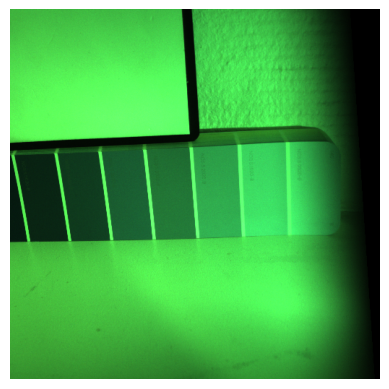

In [20]:
plt.imshow(aligned_flash)
plt.axis("off")
plt.show()

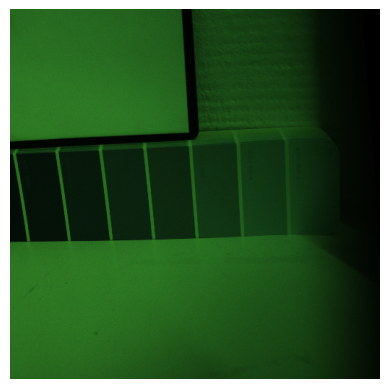

In [21]:
plt.imshow(aligned_noflash)
plt.axis("off")
plt.show()

In [22]:
import cv2
import numpy as np
import pandas as pd

collected_data = []
window_size = 5
hw = window_size // 2

def collect_data_opencv(aligned_noflash, aligned_flash, cube_31, wls_31):
    global collected_data
    collected_data = []

    display_rgb = get_approx_rgb(cube_31, wls_31)

    if display_rgb.dtype == np.float32 or display_rgb.dtype == np.float64:
        display_bgr = (np.clip(display_rgb, 0, 1) * 255).astype(np.uint8)
    else:
        display_bgr = display_rgb.copy()

    display_bgr = cv2.cvtColor(display_bgr, cv2.COLOR_RGB2BGR)
    img_disp = display_bgr.copy()

    H, W = cube_31.shape[:2]
    window_title = "Data Collector"

    def mouse_callback(event, x, y, flags, param):
        if event == cv2.EVENT_LBUTTONDOWN:
            patch_no = aligned_noflash[y-hw:y+hw+1, x-hw:x+hw+1]
            patch_fl = aligned_flash[y-hw:y+hw+1, x-hw:x+hw+1]
            patch_sp = cube_31[y-hw:y+hw+1, x-hw:x+hw+1]

            mean_no = np.mean(patch_no, axis=(0,1))
            mean_fl = np.mean(patch_fl, axis=(0,1))
            mean_sp = np.mean(patch_sp, axis=(0,1))

            row = np.concatenate([[x, y], mean_no, mean_fl, mean_sp])
            collected_data.append(row)

            cv2.circle(img_disp, (x, y), radius=3, color=(0, 255, 0), thickness=-1)
            cv2.imshow(window_title, img_disp)

            print(f"Точка ({x}, {y}) добавлена")


    cv2.namedWindow(window_title, cv2.WINDOW_NORMAL)

    cv2.resizeWindow(window_title, 1200, 800)

    cv2.setMouseCallback(window_title, mouse_callback)
    cv2.imshow(window_title, img_disp)

    cv2.waitKey(0)
    cv2.destroyAllWindows()

collect_data_opencv(aligned_noflash, aligned_flash, cube_31, wls_31)

columns = ['x', 'y', 'R', 'G', 'B', 'R_flash', 'G_flash', 'B_flash'] + [f'{int(w)}' for w in wls_31]
df_final = pd.DataFrame(collected_data, columns=columns)

df_final[['x', 'y']] = df_final[['x', 'y']].astype(int)

df_final.to_csv("my_collected_dataset_080.csv", index=False)
print(f"\nГотово! Успешно сохранено {len(df_final)} строк в файл my_collected_dataset.csv")

QObject::moveToThread: Current thread (0x23fe66e0) is not the object's thread (0x22682380).
Cannot move to target thread (0x23fe66e0)

QObject::moveToThread: Current thread (0x23fe66e0) is not the object's thread (0x22682380).
Cannot move to target thread (0x23fe66e0)

QObject::moveToThread: Current thread (0x23fe66e0) is not the object's thread (0x22682380).
Cannot move to target thread (0x23fe66e0)

QObject::moveToThread: Current thread (0x23fe66e0) is not the object's thread (0x22682380).
Cannot move to target thread (0x23fe66e0)

QObject::moveToThread: Current thread (0x23fe66e0) is not the object's thread (0x22682380).
Cannot move to target thread (0x23fe66e0)

QObject::moveToThread: Current thread (0x23fe66e0) is not the object's thread (0x22682380).
Cannot move to target thread (0x23fe66e0)

QObject::moveToThread: Current thread (0x23fe66e0) is not the object's thread (0x22682380).
Cannot move to target thread (0x23fe66e0)

QObject::moveToThread: Current thread (0x23fe66e0) is n

Точка (411, 276) добавлена
Точка (349, 276) добавлена
Точка (288, 273) добавлена
Точка (226, 275) добавлена
Точка (164, 284) добавлена
Точка (110, 286) добавлена
Точка (52, 288) добавлена

Готово! Успешно сохранено 7 строк в файл my_collected_dataset.csv


In [2]:
import numpy as np

def calculate_sam(y_true, y_pred, eps=1e-8):
    """
    Вычисляет средний Spectral Angle Mapper (в градусах) для всего датасета.
    """
    # Гарантируем, что работаем с numpy массивами
    t = np.asarray(y_true)
    p = np.asarray(y_pred)

    # Скалярное произведение по спектральной оси (axis=1)
    products = np.sum(p * t, axis=1)

    # Магнитуды (нормы векторов)
    magnitudes = np.linalg.norm(p, axis=1) * np.linalg.norm(t, axis=1) + eps

    # Косинусное сходство с обрезкой (clip), чтобы избежать ошибок из-за float
    cosine_sim = np.clip(products / magnitudes, -1.0 + eps, 1.0 - eps)

    # Переводим в радианы, затем в градусы
    angles = np.degrees(np.arccos(cosine_sim))

    # Возвращаем средний угол по всем точкам
    return np.mean(angles)

def calculate_nse(y_true, y_pred, eps=1e-8):
    """
    Вычисляет среднюю Normalized Spectral Error.
    """
    t = np.asarray(y_true)
    p = np.asarray(y_pred)

    # Сумма абсолютных разниц (по оси спектра)
    diff = np.sum(np.abs(p - t), axis=1)
    # Сумма абсолютных значений таргета
    scale = np.sum(np.abs(t), axis=1) + eps

    # Усредняем ошибку по всем точкам
    return np.mean(diff / scale)

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

file_paths = sorted(Path('.').glob('my_collected_dataset_08*.csv'))


print(f"Найдено файлов для объединения: {len(file_paths)}")

# Читаем и склеиваем
dfs = [pd.read_csv(f) for f in file_paths]
df_all = pd.concat(dfs, ignore_index=True)
print(f"Общий размер датасета: {len(df_all)} точек")

# ==========================================
# 2. ПОДГОТОВКА X и y
# ==========================================
# Базовые признаки (только RGB)
features_rgb = ['R', 'G', 'B']

# Расширенные признаки (RGB + Flash)
features_full = ['R', 'G', 'B', 'R_flash', 'G_flash', 'B_flash']

X_full = df_all[features_full]
X_rgb = df_all[features_rgb]

# Спектр — это последние 31 колонка
# (Надежно берем их с конца, чтобы не зависеть от названий)
y = df_all.iloc[:, -31:]
wavelengths = y.columns.tolist()

# ==========================================
# 3. РАЗБИЕНИЕ НА TRAIN и TEST (80% / 20%)
# ==========================================
# Разбиваем X_full и y. (X_rgb_test получим просто отрезав колонки от X_full_test)
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2)

X_train_rgb = X_train_full[features_rgb]
X_test_rgb = X_test_full[features_rgb]

# ==========================================
# 4. ОБУЧЕНИЕ МОДЕЛЕЙ
# ==========================================
# Модель 1: Только RGB
model_rgb = LinearRegression()
model_rgb.fit(X_train_rgb, y_train)

# Модель 2: RGB + Flash
model_full = LinearRegression()
model_full.fit(X_train_full, y_train)

# ==========================================
# 5. ПРЕДСКАЗАНИЯ
# ==========================================
y_pred_rgb = model_rgb.predict(X_test_rgb)
y_pred_full = model_full.predict(X_test_full)

# ==========================================
# 6. ПОДСЧЕТ МЕТРИК
# ==========================================
def calculate_metrics(y_true, y_pred, model_name):
    # Стандартные регрессионные метрики
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred, multioutput='uniform_average')

    # Спектральные метрики
    sam = calculate_sam(y_true, y_pred)
    nse = calculate_nse(y_true, y_pred)

    print(f"--- Результаты: {model_name} ---")
    print(f"RMSE:  {rmse:.4f}")
    print(f"MAE:   {mae:.4f}")
    print(f"R²:    {r2:.4f}")
    print(f"SAM:   {sam:.2f}° (чем меньше, тем точнее форма спектра)")
    print(f"NSE:   {nse:.4f}  (чем меньше, тем точнее относительная ошибка)\n")

    return rmse, mae, r2, sam, nse

print("\n" + "="*40)
calculate_metrics(y_test, y_pred_rgb, "Бейзлайн (Только RGB)")
calculate_metrics(y_test, y_pred_full, "С флэшем (RGB + RGB_flash)")

Найдено файлов для объединения: 6
Общий размер датасета: 43 точек

--- Результаты: Бейзлайн (Только RGB) ---
RMSE:  0.0809
MAE:   0.0655
R²:    0.9229
SAM:   3.04° (чем меньше, тем точнее форма спектра)
NSE:   0.1329  (чем меньше, тем точнее относительная ошибка)

--- Результаты: С флэшем (RGB + RGB_flash) ---
RMSE:  0.0479
MAE:   0.0368
R²:    0.9717
SAM:   2.50° (чем меньше, тем точнее форма спектра)
NSE:   0.0628  (чем меньше, тем точнее относительная ошибка)



(np.float64(0.04785591200108688),
 0.03677711414548553,
 0.9716573458568438,
 np.float64(2.4994717214830113),
 np.float64(0.0627852715302022))

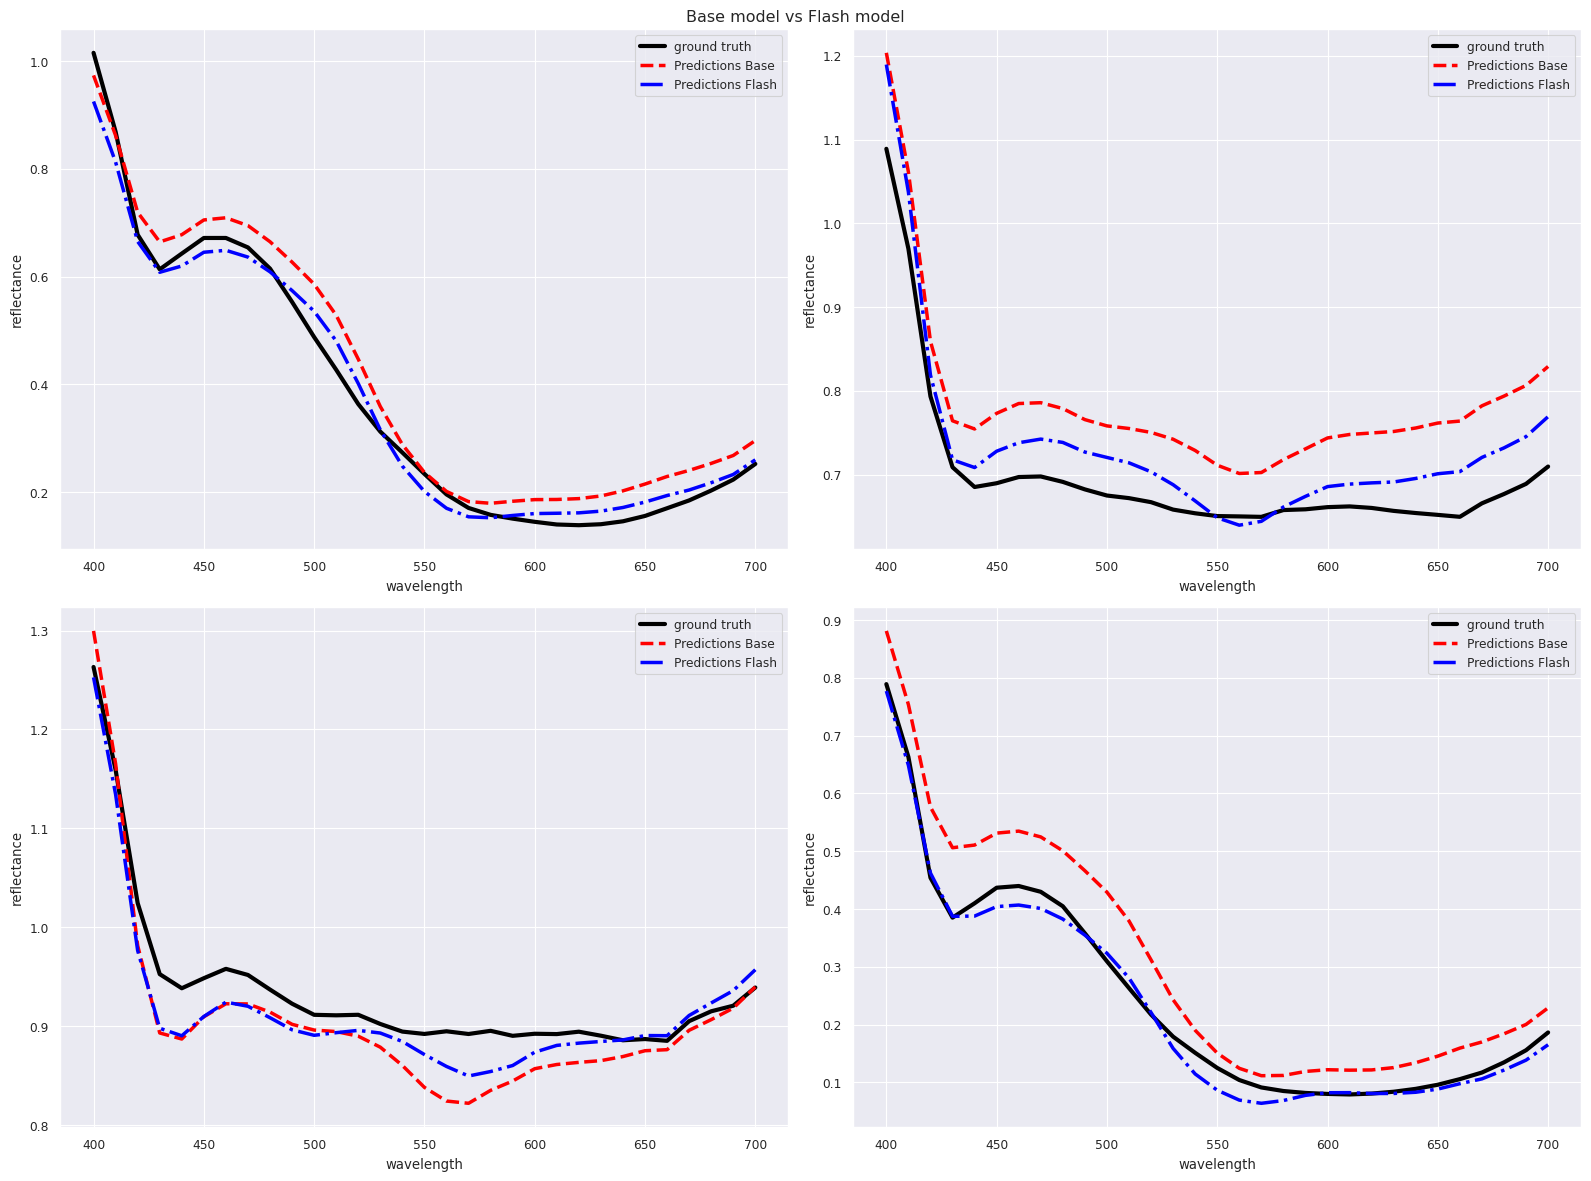

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme("paper")

# Задаем ось X: от 400 до 700 с шагом 10
wls = np.arange(400, 710, 10)

# =========================================================
# ВАРИАНТ 1: ДЕТАЛЬНОЕ СРАВНЕНИЕ (4 СЛУЧАЙНЫХ ОБРАЗЦА)
# =========================================================
# Выбираем 4 случайных индекса из тестовой выборки
num_samples = len(y_test)
random_indices = np.random.choice(num_samples, 4, replace=False)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Base model vs Flash model")

for i, ax in enumerate(axes.flatten()):
    idx = random_indices[i]

    # 1. Реальный спектр (Эталон)
    ax.plot(wls, y_test.iloc[idx], color='black', linewidth=3, label='ground truth')

    # 2. Предсказание по RGB
    ax.plot(wls, y_pred_rgb[idx], color='red', linestyle='--', linewidth=2.5, label='Predictions Base')

    # 3. Предсказание по полной модели
    ax.plot(wls, y_pred_full[idx], color='blue', linestyle='-.', linewidth=2.5, label='Predictions Flash')

    ax.set_xlabel("wavelength")
    ax.set_ylabel("reflectance")

    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme("notebook")
# Вытаскиваем длины волн в виде чисел для оси X (убираем приставку 'wl_')
wls_clean = [int(str(w).replace('wl_', '')) for w in y.columns]

# Берем первые 10 точек, чтобы не зависнуть, если их 1000.
# Замени .head(10) на df_all.iterrows(), если хочешь вывести вообще все.
for idx, row in df_all.iterrows():

    # 1. Извлекаем цвета (обязательно ограничиваем в пределах 0-1,
    # чтобы matplotlib не ругался, если где-то пиксель вылезет до 1.05)
    rgb_no = np.clip([row['R'], row['G'], row['B']], 0, 1)
    rgb_fl = np.clip([row['R_flash'], row['G_flash'], row['B_flash']], 0, 1)

    # 2. Извлекаем спектр (последние 31 число)
    spectrum = row[-31:].values

    # 3. Рисуем. Делаем одну маленькую фигуру на каждую итерацию.
    # width_ratios делает график в 4 раза шире квадратиков
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 2), gridspec_kw={'width_ratios': [1, 1, 4]})

    # --- Квадратик No Flash ---
    ax1.imshow([[rgb_no]])
    ax1.axis('off')
    ax1.set_title("No Flash")

    # --- Квадратик Flash ---
    ax2.imshow([[rgb_fl]])
    ax2.axis('off')
    ax2.set_title("Flash")

    # --- График спектра ---
    ax3.plot(wls_clean, spectrum, color='black', linewidth=2)
    ax3.set_title(f"Точка #{idx} (Координаты: {row['x']:.0f}, {row['y']:.0f})")
    ax3.set_xlabel("Длина волны (нм)")
    ax3.set_ylim(0, 1.1) # Жестко фиксируем высоту, чтобы графики было легко сравнивать визуально
    ax3.grid(True, alpha=0.3)

    # Показываем строку и переходим к следующей
    plt.tight_layout()
    plt.show()

In [7]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet

file_paths = sorted(Path('.').glob('my_collected_dataset_08*.csv'))


print(f"Найдено файлов для объединения: {len(file_paths)}")

# Читаем и склеиваем
dfs = [pd.read_csv(f) for f in file_paths]
df_all = pd.concat(dfs, ignore_index=True)
print(f"Общий размер датасета: {len(df_all)} точек")

# ==========================================
# 2. ПОДГОТОВКА X и y
# ==========================================
# Базовые признаки (только RGB)
features_rgb = ['R', 'G', 'B']

# Расширенные признаки (RGB + Flash)
features_full = ['R', 'G', 'B', 'R_flash', 'G_flash', 'B_flash']

X_full = df_all[features_full]
X_rgb = df_all[features_rgb]

# Спектр — это последние 31 колонка
# (Надежно берем их с конца, чтобы не зависеть от названий)
y = df_all.iloc[:, -31:]
wavelengths = y.columns.tolist()


import numpy as np
from sklearn.model_selection import RepeatedKFold, cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.linear_model import LinearRegression
from scipy import stats

# ==========================================
# 1. ОБЕРТКИ ДЛЯ МЕТРИК
# ==========================================
# (Убедись, что функции calculate_sam и calculate_nse объявлены в коде до этого момента)

# Создаем словарь метрик.
# greater_is_better=False говорит sklearn, что алгоритм должен минимизировать эту метрику.
# (Из-за этого sklearn будет выдавать результаты со знаком минус, мы исправим это при выводе).
scoring_metrics = {
    'RMSE': make_scorer(lambda y_t, y_p: np.sqrt(mean_squared_error(y_t, y_p)), greater_is_better=False),
    'MAE':  make_scorer(mean_absolute_error, greater_is_better=False),
    'R2':   make_scorer(r2_score, multioutput='uniform_average'), # Тут больше = лучше
    'SAM':  make_scorer(calculate_sam, greater_is_better=False),
    'NSE':  make_scorer(calculate_nse, greater_is_better=False)
}

# ==========================================
# 2. НАСТРОЙКА И ЗАПУСК КРОСС-ВАЛИДАЦИИ
# ==========================================
cv = RepeatedKFold(n_splits=5, n_repeats=10, random_state=42)
model = LinearRegression()


print("Запускаем 50 прогонов (5 фолдов x 10 повторений) для всех метрик...\n")

# Оцениваем модель ТОЛЬКО по RGB
results_rgb = cross_validate(model, X_rgb, y, scoring=scoring_metrics, cv=cv, n_jobs=-1)

# Оцениваем модель RGB + Flash
results_full = cross_validate(model, X_full, y, scoring=scoring_metrics, cv=cv, n_jobs=-1)

# ==========================================
# 3. АНАЛИЗ И ВЫВОД РЕЗУЛЬТАТОВ
# ==========================================
# Словарь с настройками: какие метрики нужно минимизировать, а какие - максимизировать
metrics_info = {
    'RMSE': {'lower_is_better': True,  'unit': ''},
    'MAE':  {'lower_is_better': True,  'unit': ''},
    'R2':   {'lower_is_better': False, 'unit': ''},
    'SAM':  {'lower_is_better': True,  'unit': '°'},
    'NSE':  {'lower_is_better': True,  'unit': ''}
}

for metric_name, info in metrics_info.items():
    key = f'test_{metric_name}'

    # Извлекаем массивы (по 50 значений в каждом)
    val_rgb = results_rgb[key]
    val_full = results_full[key]

    # Убираем технический минус от sklearn для метрик ошибок
    if info['lower_is_better']:
        val_rgb = -val_rgb
        val_full = -val_full

    mean_rgb, std_rgb = np.mean(val_rgb), np.std(val_rgb)
    mean_full, std_full = np.mean(val_full), np.std(val_full)

    # Вычисляем разницу и процент улучшения
    if info['lower_is_better']:
        diff = mean_rgb - mean_full
        improvement_pct = (diff / mean_rgb) * 100
        is_improved = diff > 0
    else:
        diff = mean_full - mean_rgb
        # Используем модуль для R2, так как в плохих случаях R2 бывает отрицательным
        improvement_pct = (diff / np.abs(mean_rgb)) * 100
        is_improved = diff > 0

    # Парный t-тест
    t_stat, p_value = stats.ttest_rel(val_rgb, val_full)
    is_significant = p_value < 0.05

    # Форматируем вывод
    print("=" * 50)
    print(f"МЕТРИКА: {metric_name} (Чем {'меньше' if info['lower_is_better'] else 'больше'}, тем лучше)")
    print("-" * 50)
    print(f"Только RGB: {mean_rgb:.4f} ± {std_rgb:.4f} {info['unit']}")
    print(f"RGB+Flash:  {mean_full:.4f} ± {std_full:.4f} {info['unit']}")

    if is_improved:
        print(f"Улучшение:  {np.abs(diff):.4f} {info['unit']} (+{improvement_pct:.1f}%)")
    else:
        print(f"УХУДШЕНИЕ:  {np.abs(diff):.4f} {info['unit']} ({improvement_pct:.1f}%)")

    print(f"P-value:    {p_value:.3e}")

    if is_significant and is_improved:
        print("ВЕРДИКТ:    ✅ Значимое улучшение (Флэш работает!)")
    elif is_significant and not is_improved:
        print("ВЕРДИКТ:    ❌ Значимое ухудшение (Переобучение или шум)")
    else:
        print("ВЕРДИКТ:    ⚠️ Статистически неразличимы (Слишком мало данных или разницы нет)")

print("\n" + "=" * 50)

Найдено файлов для объединения: 6
Общий размер датасета: 43 точек
Запускаем 50 прогонов (5 фолдов x 10 повторений) для всех метрик...

МЕТРИКА: RMSE (Чем меньше, тем лучше)
--------------------------------------------------
Только RGB: 0.0882 ± 0.0327 
RGB+Flash:  0.0690 ± 0.0260 
Улучшение:  0.0192  (+21.8%)
P-value:    2.134e-12
ВЕРДИКТ:    ✅ Значимое улучшение (Флэш работает!)
МЕТРИКА: MAE (Чем меньше, тем лучше)
--------------------------------------------------
Только RGB: 0.0641 ± 0.0171 
RGB+Flash:  0.0502 ± 0.0131 
Улучшение:  0.0139  (+21.6%)
P-value:    2.051e-10
ВЕРДИКТ:    ✅ Значимое улучшение (Флэш работает!)
МЕТРИКА: R2 (Чем больше, тем лучше)
--------------------------------------------------
Только RGB: 0.8580 ± 0.1207 
RGB+Flash:  0.9150 ± 0.0716 
Улучшение:  0.0570  (+6.6%)
P-value:    6.875e-09
ВЕРДИКТ:    ✅ Значимое улучшение (Флэш работает!)
МЕТРИКА: SAM (Чем меньше, тем лучше)
--------------------------------------------------
Только RGB: 3.2778 ± 0.4561 °
RGB+Fla

In [8]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from scipy.optimize import minimize
from scipy.interpolate import interp1d
import seaborn as sns

sns.set_theme("paper")

In [9]:
file_paths = sorted(Path('.').glob('my_collected_dataset_08*.csv'))


print(f"Найдено файлов для объединения: {len(file_paths)}")

# Читаем и склеиваем
dfs = [pd.read_csv(f) for f in file_paths]
real_data = pd.concat(dfs, ignore_index=True)
print(f"Общий размер датасета: {len(df_all)} точек")

# ==========================================
# 2. ПОДГОТОВКА X и y
# ==========================================
# Базовые признаки (только RGB)
features_rgb = ['R', 'G', 'B']

# Расширенные признаки (RGB + Flash)
features_full = ['R', 'G', 'B', 'R_flash', 'G_flash', 'B_flash']

X_with_flash = real_data[features_full]
X_no_flash = real_data[features_rgb]

# Спектр — это последние 31 колонка
# (Надежно берем их с конца, чтобы не зависеть от названий)
y = real_data.iloc[:, -31:]
wavelengths = y.columns.tolist()

Найдено файлов для объединения: 6
Общий размер датасета: 43 точек


Матрица чувствительности (31, 3)


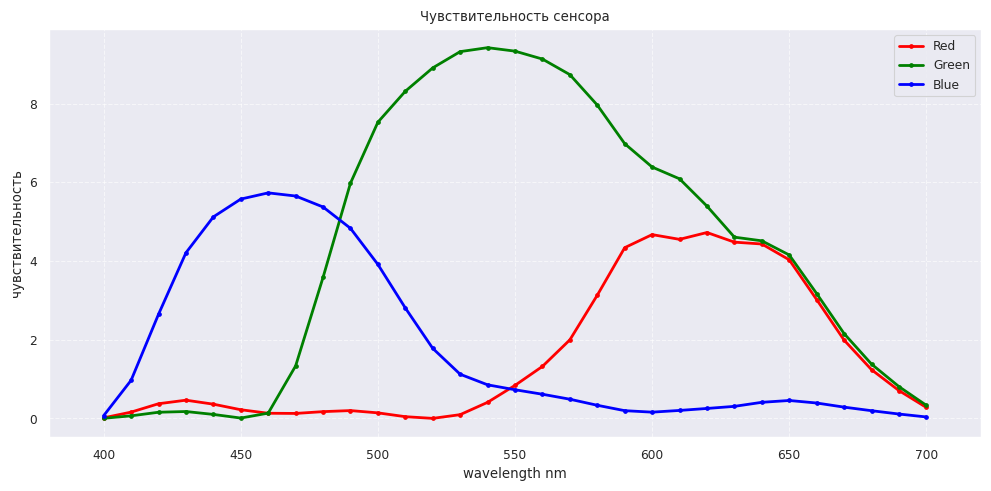

In [10]:
csv_path = "sensitivities-main.csv"
df_cam = pd.read_csv(csv_path)

df_cam.columns = df_cam.columns.str.lower()

cam_wls = df_cam['wavelength'].values
cam_r = df_cam['r'].values
cam_g = df_cam['g'].values
cam_b = df_cam['b'].values

target_wls = np.linspace(400, 700, 31)

interp_r = interp1d(cam_wls, cam_r, kind='linear', bounds_error=False, fill_value=0)
interp_g = interp1d(cam_wls, cam_g, kind='linear', bounds_error=False, fill_value=0)
interp_b = interp1d(cam_wls, cam_b, kind='linear', bounds_error=False, fill_value=0)

sens_r_31 = interp_r(target_wls)
sens_g_31 = interp_g(target_wls)
sens_b_31 = interp_b(target_wls)

sensor = np.column_stack((sens_r_31, sens_g_31, sens_b_31))

sensor = np.clip(sensor, 0, None)

print(f"Матрица чувствительности {sensor.shape}")

plt.figure(figsize=(10, 5))
plt.plot(target_wls, sensor[:, 0], color='red', linewidth=2, marker='.', label='Red')
plt.plot(target_wls, sensor[:, 1], color='green', linewidth=2, marker='.', label='Green')
plt.plot(target_wls, sensor[:, 2], color='blue', linewidth=2, marker='.', label='Blue')

plt.title("Чувствительность сенсора")
plt.xlabel("wavelength nm")
plt.ylabel("чувствительность")
plt.xlim(380, 720)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
def get_gradient_matrix(n=31):
    nabla = np.zeros((n, n))

    # матрица полностью из статьи
    for i in range(1, n-1):
        nabla[i, i] = -1
        nabla[i, i+1] = 1

    val_edge = 1 / np.sqrt(2)
    nabla[0, 0] = -val_edge
    nabla[0, 1] = val_edge

    nabla[-1, -2] = -val_edge
    nabla[-1, -1] = val_edge

    return nabla

nabla = get_gradient_matrix(31)
Q = nabla.T @ nabla

In [13]:
def estimate_reflectance(rgb_target, sensor_matrix, light_spectrum):
    """
    rgb_target: [R, G, B] - сигнал с камеры
    sensor_matrix: (N, 3) - чувствительность каналов
    light_spectrum: (N,) - спектр источника (например, D65)
    """
    n = len(light_spectrum)

    A = (sensor_matrix * light_spectrum[:, np.newaxis]).T

    nabla = get_gradient_matrix(n)
    Q = nabla.T @ nabla
    def objective(s):
        return s.T @ Q @ s

    constraints = [{'type': 'eq', 'fun': lambda s: A @ s - rgb_target}]

    bounds = [(0, 1) for _ in range(n)]

    s0 = np.full(n, 0.5)

    res = minimize(objective, s0, method='SLSQP', bounds=bounds, constraints=constraints)

    return res.x

In [14]:
wavelengths_str = "370.000000 373.000000 377.000000 380.000000 383.000000 387.000000 390.000000 393.000000 397.000000 400.000000 403.000000 407.000000 410.000000 413.000000 417.000000 420.000000 423.000000 427.000000 430.000000 433.000000 437.000000 440.000000 443.000000 447.000000 450.000000 453.000000 457.000000 460.000000 463.000000 467.000000 470.000000 473.000000 477.000000 480.000000 483.000000 487.000000 490.000000 493.000000 497.000000 500.000000 503.000000 507.000000 510.000000 513.000000 517.000000 520.000000 523.000000 527.000000 530.000000 533.000000 537.000000 540.000000 543.000000 547.000000 550.000000 553.000000 557.000000 560.000000 563.000000 567.000000 570.000000 573.000000 577.000000 580.000000 583.000000 587.000000 590.000000 593.000000 597.000000 600.000000 603.000000 607.000000 610.000000 613.000000 617.000000 620.000000 623.000000 627.000000 630.000000 633.000000 637.000000 640.000000 643.000000 647.000000 650.000000 653.000000 657.000000 660.000000 663.000000 667.000000 670.000000 673.000000 677.000000 680.000000 683.000000 687.000000 690.000000 693.000000 697.000000 700.000000 703.000000 707.000000 710.000000 713.000000 717.000000 720.000000 723.000000 727.000000 730.000000"
values_str = "0.013979 0.00982097 0.00649137 0.0053779 0.00306603 0.00318108 0.00181273 0.00361689 0.00170022 0.000704909 0.00480284 0.00488461 0.00666502 0.0084493 0.0164837 0.0274815 0.0458242 0.0785095 0.130158 0.204246 0.314031 0.467073 0.683143 1.00655 1.47064 2.03377 2.49899 2.62177 2.3825 2.0281 1.76402 1.58175 1.40909 1.25038 1.13518 1.07648 1.06196 1.06872 1.07378 1.0803 1.09442 1.10739 1.10228 1.0923 1.09413 1.10214 1.09587 1.06673 1.0343 1.01897 1.02444 1.03571 1.03199 1.02317 1.02604 1.03317 1.0297 1.00846 0.982845 0.971082 0.968183 0.966375 0.965639 0.962495 0.954812 0.935454 0.911705 0.894161 0.89661 0.910285 0.91287 0.894728 0.873999 0.864706 0.869985 0.882184 0.882458 0.864757 0.83927 0.813802 0.794647 0.776322 0.757521 0.73873 0.715607 0.690349 0.652257 0.61286 0.579377 0.557233 0.53842 0.523425 0.498968 0.471737 0.445814 0.415325 0.389388 0.371083 0.341187 0.30784 0.286542 0.255436 0.22745 0.207977 0.19008 0.179479 0.174373 0.16649 0.143163"

argyll_wls = np.array([float(x) for x in wavelengths_str.split()])
argyll_vals = np.array([float(x) for x in values_str.split()])

target_wls = np.linspace(400, 700, 31)
interp_func = interp1d(argyll_wls, argyll_vals, kind='linear', bounds_error=False, fill_value="extrapolate")
flash_spectrum = interp_func(target_wls)
flash_spectrum = np.clip(flash_spectrum, 0, None)
flash_spectrum = flash_spectrum / flash_spectrum.sum(axis=0)

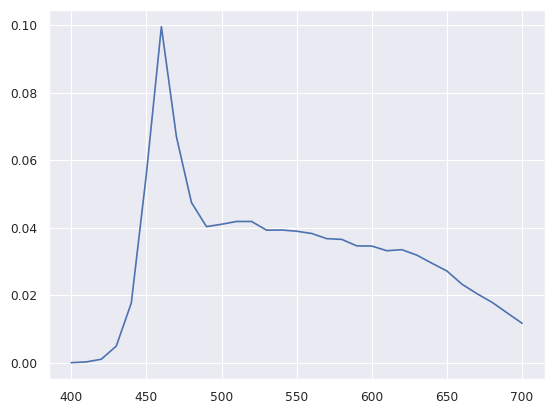

In [15]:
x = range(400, 705, 10)
y = flash_spectrum

sns.lineplot(x=x, y=y)
plt.show()

In [16]:
flash_spectrum = flash_spectrum / 2

In [17]:
real_data.columns


Index(['x', 'y', 'R', 'G', 'B', 'R_flash', 'G_flash', 'B_flash', '400', '410',
       '420', '430', '440', '450', '460', '470', '480', '490', '500', '510',
       '520', '530', '540', '550', '560', '570', '580', '590', '600', '610',
       '620', '630', '640', '650', '660', '670', '680', '690', '700'],
      dtype='object')

In [18]:
import numpy as np
import pandas as pd
from tqdm import tqdm # Библиотека для красивого прогресс-бара
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ==========================================
# 1. ПОДГОТОВКА ДАННЫХ
# ==========================================
# Извлекаем эталонные спектры (Ground Truth) — колонки с '400' по '700'
y_true = real_data.loc[:, '400':'700'].values

# Извлекаем входные цвета.
# Выбери нужный вариант:
# Вариант А: Обычное освещение
rgb_inputs = real_data[['R_flash', 'G_flash', 'B_flash']].values - real_data[['R', 'G', 'B']].values

# Вариант Б: Если хочешь прогнать данные от вспышки
# rgb_inputs = real_data[['R_flash', 'G_flash', 'B_flash']].values

# ==========================================
# 2. ЗАПУСК ОПТИМИЗАЦИИ ДЛЯ ВСЕХ ТОЧЕК
# ==========================================
y_pred_list = []

print(f"Запускаем реконструкцию спектра для {len(rgb_inputs)} точек...")

# tqdm обернет наш массив и покажет время до конца
for rgb in tqdm(rgb_inputs, desc="Оптимизация (SLSQP)"):
    recovered_s = estimate_reflectance(rgb, sensor, flash_spectrum)
    y_pred_list.append(recovered_s)

# Превращаем список предсказаний в удобную матрицу NumPy
y_pred = np.array(y_pred_list)

# ==========================================
# 3. ФУНКЦИИ МЕТРИК И ВЫВОД РЕЗУЛЬТАТОВ
# ==========================================
def calculate_sam(y_t, y_p, eps=1e-8):
    products = np.sum(y_p * y_t, axis=1)
    magnitudes = np.linalg.norm(y_p, axis=1) * np.linalg.norm(y_t, axis=1) + eps
    cosine_sim = np.clip(products / magnitudes, -1.0 + eps, 1.0 - eps)
    angles = np.degrees(np.arccos(cosine_sim))
    return np.mean(angles)

def calculate_nse(y_t, y_p, eps=1e-8):
    diff = np.sum(np.abs(y_p - y_t), axis=1)
    scale = np.sum(np.abs(y_t), axis=1) + eps
    return np.mean(diff / scale)

def print_final_metrics(y_true, y_pred, model_name="Аналитическая оптимизация"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred, multioutput='uniform_average')
    sam = calculate_sam(y_true, y_pred)
    nse = calculate_nse(y_true, y_pred)

    print("\n" + "="*50)
    print(f"=== Результаты: {model_name} ===")
    print("="*50)
    print(f"RMSE:  {rmse:.4f} (Чем меньше, тем лучше)")
    print(f"MAE:   {mae:.4f} (Чем меньше, тем лучше)")
    print(f"R²:    {r2:.4f} (Ближе к 1.0 — лучше)")
    print(f"SAM:   {sam:.2f}° (Точность формы спектра, < 5° = отлично)")
    print(f"NSE:   {nse:.4f}  (Относительная ошибка)")
    print("="*50)

# Вызываем расчет метрик
print_final_metrics(y_true, y_pred)

Запускаем реконструкцию спектра для 43 точек...


Оптимизация (SLSQP): 100%|██████████| 43/43 [00:01<00:00, 42.86it/s]


=== Результаты: Аналитическая оптимизация ===
RMSE:  0.3857 (Чем меньше, тем лучше)
MAE:   0.3116 (Чем меньше, тем лучше)
R²:    -1.5331 (Ближе к 1.0 — лучше)
SAM:   23.51° (Точность формы спектра, < 5° = отлично)
NSE:   0.6419  (Относительная ошибка)


<Figure size 800x800 with 0 Axes>

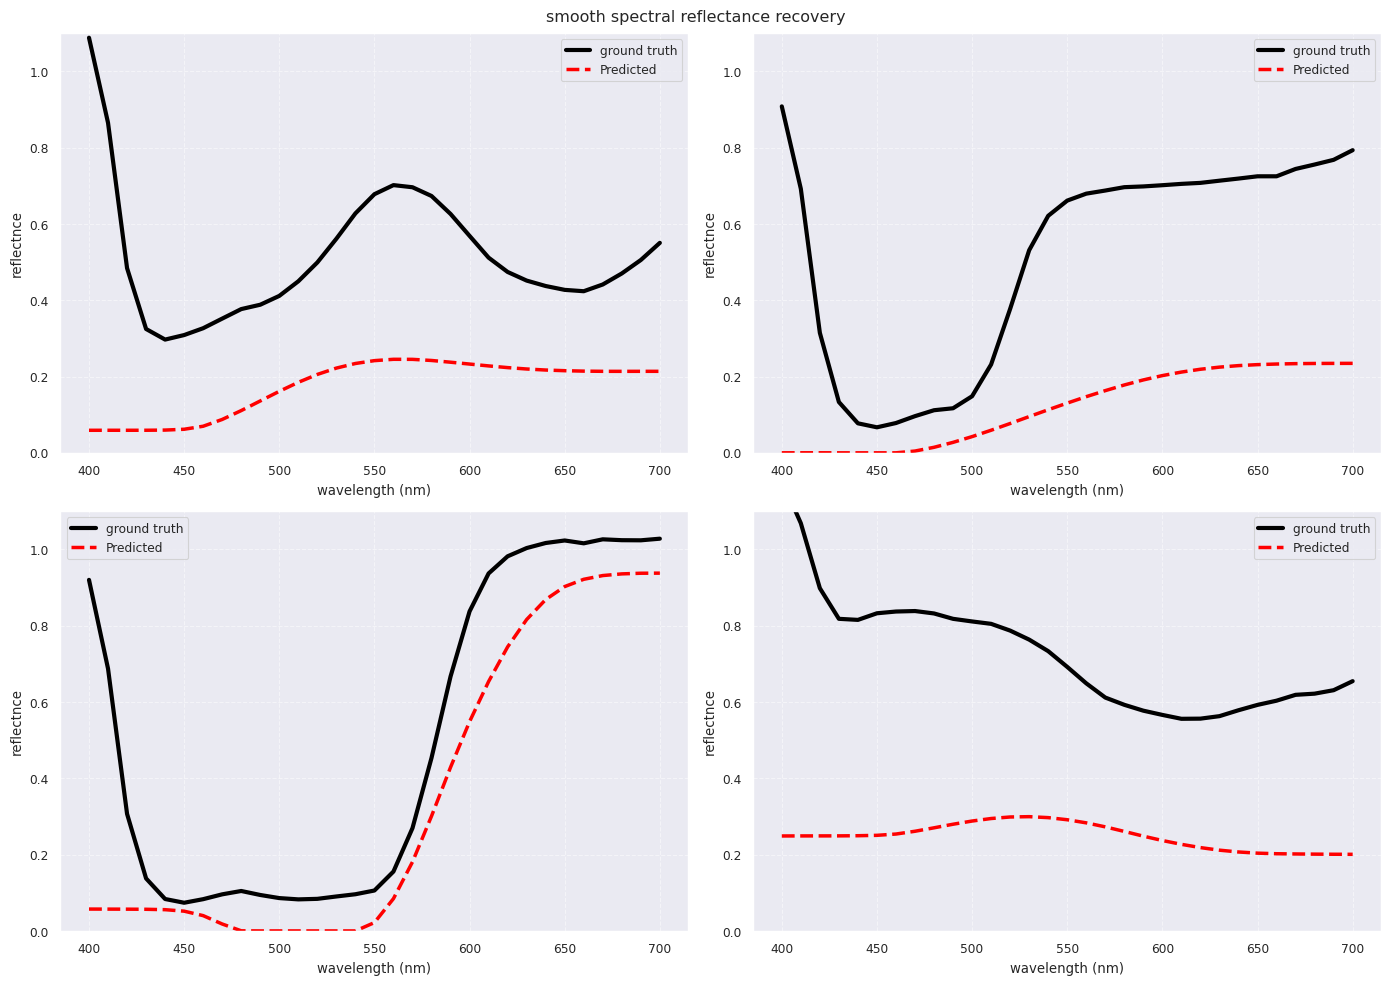

In [51]:
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme('paper')
# Задаем ось X для спектров (наши 31 длина волны от 400 до 700 нм)
wls = np.linspace(400, 700, 31)

# ==========================================
# 1. ГЛОБАЛЬНЫЙ SCATTER PLOT (ВСЕ ТОЧКИ)
# ==========================================
plt.figure(figsize=(8, 8))

# Вытягиваем матрицы (N, 31) в одномерные массивы для общего сравнения
y_true_flat = y_true.flatten()
y_pred_flat = y_pred.flatten()

# # Рисуем точки. Делаем их полупрозрачными (alpha), чтобы видеть плотность
# plt.scatter(y_true_flat, y_pred_flat, alpha=0.05, s=10, color='blue')
#
# # Рисуем идеальную линию y = x (где предсказание идеально совпадает с реальностью)
# plt.plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=2, label='Идеал (y = x)')
#
# plt.title("Общее качество предсказаний: Pred vs True", fontsize=14)
# plt.xlabel("Реальное отражение (Ground Truth)", fontsize=12)
# plt.ylabel("Предсказанное отражение", fontsize=12)
# plt.xlim(0, 1.1)
# plt.ylim(0, 1.1)
# plt.grid(True, linestyle='--', alpha=0.6)
# plt.legend()
# plt.show()

# ==========================================
# 2. ДЕТАЛЬНОЕ СРАВНЕНИЕ СПЕКТРОВ (4 СЛУЧАЙНЫЕ ТОЧКИ)
# ==========================================
# Выбираем 4 случайных индекса из датасета
num_samples = len(y_true)
random_indices = np.random.choice(num_samples, 4, replace=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("smooth spectral reflectance recovery")

for i, ax in enumerate(axes.flatten()):
    idx = random_indices[i]

    # Реальный спектр
    ax.plot(wls, y_true[idx], color='black', linewidth=3, label='ground truth')

    # Предсказанный спектр
    ax.plot(wls, y_pred[idx], color='red', linestyle='--', linewidth=2.5, label='Predicted')

    ax.set_xlabel("wavelength (nm)")
    ax.set_ylabel("reflectnce")
    ax.set_ylim(0, 1.1)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()

plt.tight_layout()
plt.show()

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

print("=== ЭТАП 1: ГЕНЕРАЦИЯ СИНТЕТИКИ ===")
# 1. Собираем матрицу системы A (3 канала x 31 длина волны)
# Точно так же, как внутри функции estimate_reflectance
A_matrix = (sensor * flash_spectrum[:, np.newaxis]).T

# 2. Умножаем матрицу A на реальные спектры
# y_true имеет размер (N, 31). Транспонируем в (31, N), умножаем, и возвращаем в (N, 3)
rgb_synthetic = (A_matrix @ y_true.T).T

print(f"Сгенерировано {len(rgb_synthetic)} синтетических RGB значений.")
print(f"Пример первого RGB: {rgb_synthetic[0]}")

print("\n=== ЭТАП 2: ЗАПУСК ОПТИМИЗАТОРА НА СИНТЕТИКЕ ===")
y_pred_synth_list = []

for rgb in tqdm(rgb_synthetic, desc="Оптимизация на синтетике"):
    # Передаем наши ИДЕАЛЬНЫЕ rgb
    recovered_s = estimate_reflectance(rgb, sensor, flash_spectrum)
    y_pred_synth_list.append(recovered_s)

y_pred_synth = np.array(y_pred_synth_list)

# Выводим метрики (функция print_final_metrics из предыдущего шага)
print_final_metrics(y_true, y_pred_synth, model_name="Синтетические данные (Без шума)")

=== ЭТАП 1: ГЕНЕРАЦИЯ СИНТЕТИКИ ===
Сгенерировано 43 синтетических RGB значений.
Пример первого RGB: [0.52449285 2.00057196 1.11530704]

=== ЭТАП 2: ЗАПУСК ОПТИМИЗАТОРА НА СИНТЕТИКЕ ===


Оптимизация на синтетике: 100%|██████████| 43/43 [00:01<00:00, 42.63it/s]


=== Результаты: Синтетические данные (Без шума) ===
RMSE:  0.1533 (Чем меньше, тем лучше)
MAE:   0.0677 (Чем меньше, тем лучше)
R²:    0.3348 (Ближе к 1.0 — лучше)
SAM:   16.06° (Точность формы спектра, < 5° = отлично)
NSE:   0.1502  (Относительная ошибка)


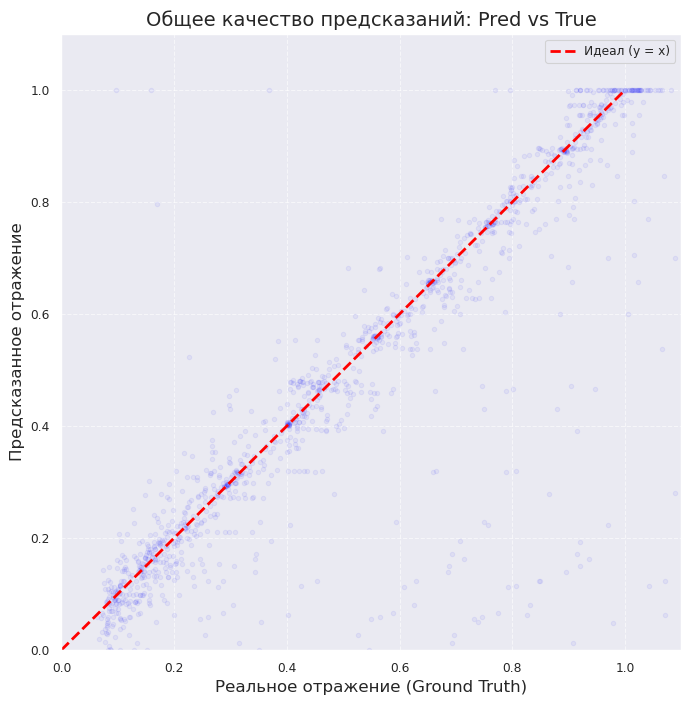

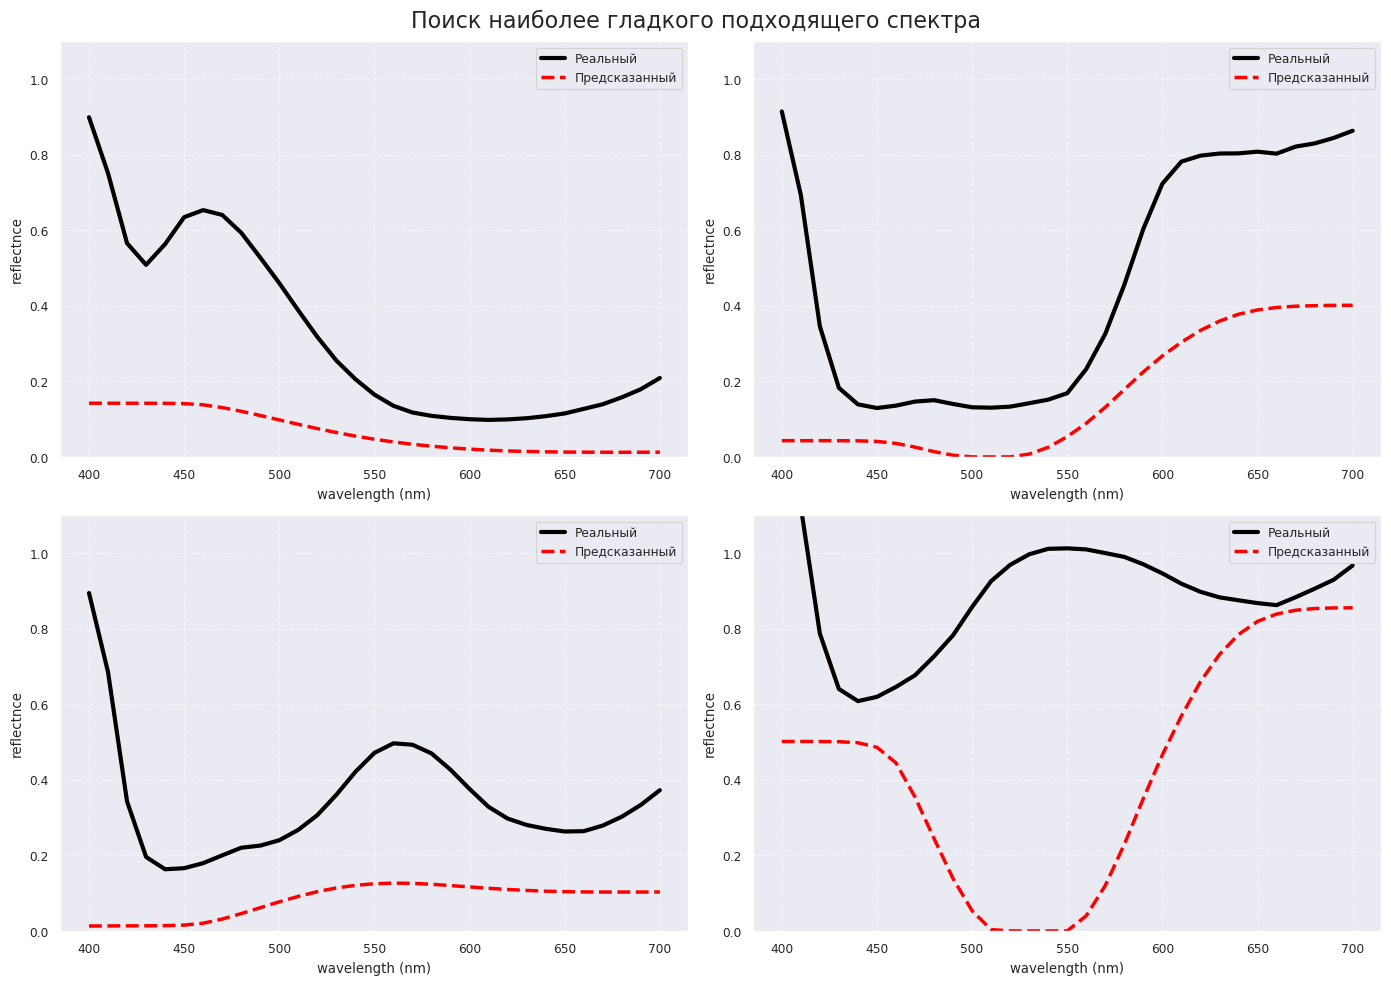

In [24]:
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme('paper')
# Задаем ось X для спектров (наши 31 длина волны от 400 до 700 нм)
wls = np.linspace(400, 700, 31)

# ==========================================
# 1. ГЛОБАЛЬНЫЙ SCATTER PLOT (ВСЕ ТОЧКИ)
# ==========================================
plt.figure(figsize=(8, 8))

# Вытягиваем матрицы (N, 31) в одномерные массивы для общего сравнения
y_true_flat = y_true.flatten()
y_pred_flat = y_pred_synth.flatten()

# Рисуем точки. Делаем их полупрозрачными (alpha), чтобы видеть плотность
plt.scatter(y_true_flat, y_pred_flat, alpha=0.05, s=10, color='blue')

# Рисуем идеальную линию y = x (где предсказание идеально совпадает с реальностью)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=2, label='Идеал (y = x)')

plt.title("Общее качество предсказаний: Pred vs True", fontsize=14)
plt.xlabel("Реальное отражение (Ground Truth)", fontsize=12)
plt.ylabel("Предсказанное отражение", fontsize=12)
plt.xlim(0, 1.1)
plt.ylim(0, 1.1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# ==========================================
# 2. ДЕТАЛЬНОЕ СРАВНЕНИЕ СПЕКТРОВ (4 СЛУЧАЙНЫЕ ТОЧКИ)
# ==========================================
# Выбираем 4 случайных индекса из датасета
num_samples = len(y_true)
random_indices = np.random.choice(num_samples, 4, replace=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Поиск наиболее гладкого подходящего спектра", fontsize=16)

for i, ax in enumerate(axes.flatten()):
    idx = random_indices[i]

    # Реальный спектр
    ax.plot(wls, y_true[idx], color='black', linewidth=3, label='Реальный')

    # Предсказанный спектр
    ax.plot(wls, y_pred[idx], color='red', linestyle='--', linewidth=2.5, label='Предсказанный')

    ax.set_xlabel("wavelength (nm)")
    ax.set_ylabel("reflectnce")
    ax.set_ylim(0, 1.1)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()

plt.tight_layout()
plt.show()